# Fixed DQN + Stable Baselines3 for EV2Gym 🚗⚡

This notebook includes:
1. **Fixed DQN** - Addresses Q-value explosion, loss increase, convergence issues
2. **Stable Baselines3** - Production-ready TD3, SAC, DDPG with continuous actions
3. **Comprehensive comparison** - Compare all methods with baselines

## Issues Fixed from Previous Version:
- ❌ Q-value explosion (0 → 200)
- ❌ Loss increasing instead of decreasing
- ❌ No convergence in tracking error
- ❌ Action space limitation (all ports same value)

## Solutions Applied:
- ✅ Q-value clipping
- ✅ Double DQN to prevent overestimation
- ✅ Lower learning rate (1e-5)
- ✅ Simpler reward function
- ✅ Continuous actions with TD3/SAC (Stable Baselines3)

## Part 1: Setup and Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from collections import namedtuple, deque
from itertools import count
import random
import math
import pickle
import json

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Change to project root directory (needed for EV2Gym data paths)
# If running in Jupyter, this will be the tutorials/ directory
if os.path.basename(os.getcwd()) == 'tutorials':
    os.chdir('..')
print(f"Working directory: {os.getcwd()}")

from ev2gym.models.ev2gym_env import EV2Gym

# Import Stable Baselines3 and Gym
import gymnasium as gym
from stable_baselines3 import TD3, SAC, DDPG
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.noise import NormalActionNoise

# Import reward and state functions from ev2gym
from ev2gym.rl_agent.reward import SquaredTrackingErrorReward
from ev2gym.rl_agent.state import PublicPST

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Working directory: /Users/josepedroevans/Desktop/MECD/TASI/EV2Gym


/Users/josepedroevans/Desktop/MECD/TASI/EV2Gym/ev2gym/utilities/loaders.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using device: cpu


## Part 2: Choose Your Approach

**Recommendation**: Start with Stable Baselines3 (Skip to Part 4) for best results.

- **Part 3**: Fixed DQN (discrete actions, all ports controlled identically)
- **Part 4**: Stable Baselines3 TD3/SAC (continuous actions, independent port control) ⭐ **Recommended**

---
# Part 3: Fixed DQN Implementation

This section contains the fixed DQN with all stability improvements.

### 3.1: Fixed DQN Configuration

In [3]:
# ============================================================================
# FIXED DQN CONFIGURATION
# ============================================================================

DQN_CONFIG = {
    "num_episodes": 500,
    "batch_size": 32,        # Smaller for stability
    "lr": 1e-5,              # MUCH lower than before (was 5e-5)
    "gamma": 0.90,           # Lower discount factor
    "eps_start": 1.0,
    "eps_end": 0.05,
    "eps_decay": 10000,      # Slower decay
    "tau": 0.001,            # Slower target updates (was 0.005)
    "memory_size": 50000,
    "n_actions": 11,
    "hidden_size": 64,       # Smaller network (was 128)
    "use_double_dqn": True,  # NEW: Double DQN
    "clip_q_values": True,   # NEW: Q-value clipping
    "q_clip_min": -10,
    "q_clip_max": 10,
    "gradient_clip": 1.0,    # Lower gradient clipping (was 10.0)
    "print_freq": 10,
    "save_freq": 50,
}

print("Fixed DQN Configuration:")
print("=" * 70)
for key, value in DQN_CONFIG.items():
    print(f"  {key:20s}: {value}")
print("=" * 70)

Fixed DQN Configuration:
  num_episodes        : 500
  batch_size          : 32
  lr                  : 1e-05
  gamma               : 0.9
  eps_start           : 1.0
  eps_end             : 0.05
  eps_decay           : 10000
  tau                 : 0.001
  memory_size         : 50000
  n_actions           : 11
  hidden_size         : 64
  use_double_dqn      : True
  clip_q_values       : True
  q_clip_min          : -10
  q_clip_max          : 10
  gradient_clip       : 1.0
  print_freq          : 10
  save_freq           : 50


### 3.2: Environment Setup for DQN

In [4]:
# Setup paths
config_file = "ev2gym/example_config_files/PublicPST.yaml"

# Create environment
dqn_env = EV2Gym(
    config_file=config_file,
    render_mode=False,
    seed=42,
    save_plots=False,
    save_replay=False,
    verbose=False
)

# Get environment info
state, _ = dqn_env.reset()
n_observations = len(state)
total_ports = sum(cs.n_ports for cs in dqn_env.charging_stations)

print(f"State dimension: {n_observations}")
print(f"Total ports: {total_ports}")
print(f"Simulation length: {dqn_env.simulation_length} steps")
print(f"Number of charging stations: {len(dqn_env.charging_stations)}")

# Action discretization
def discretize_action(action_idx, n_actions=DQN_CONFIG['n_actions']):
    value = action_idx / (n_actions - 1)
    return [value] * total_ports

print(f"\nAction discretization: {DQN_CONFIG['n_actions']} discrete levels")

State dimension: 63
Total ports: 20
Simulation length: 112 steps
Number of charging stations: 20

Action discretization: 11 discrete levels


### 3.3: Simple Reward Function

In [5]:
def reward_normalized_simple(env, *args):
    """
    Normalized tracking reward - SIMPLE and STABLE.
    This is the same as Helena's v2 but without the multi-objective complexity.
    """
    error = min(env.power_setpoints[env.current_step-1],
                env.charge_power_potential[env.current_step-1]) - \
            env.current_power_usage[env.current_step-1]
    squared_error = error ** 2

    max_possible = max(abs(env.power_setpoints[env.current_step-1]),
                       abs(env.charge_power_potential[env.current_step-1]))
    max_squared_error = max_possible ** 2 if max_possible > 0 else 1

    reward = -squared_error / max_squared_error

    # Small bonus for excellent tracking
    if abs(error) < 0.05 * max_possible:
        reward += 0.1

    return max(-1, min(reward, 0.1))

# Set reward function
dqn_env.set_reward_function(reward_normalized_simple)
print("Using simplified normalized reward function")

Using simplified normalized reward function


### 3.4: Simple DQN with Batch Normalization

In [6]:
class SimpleDQN(nn.Module):
    """Simple DQN with batch normalization."""
    def __init__(self, n_observations, n_actions, hidden_size=64):
        super(SimpleDQN, self).__init__()
        
        self.fc1 = nn.Linear(n_observations, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.fc3 = nn.Linear(hidden_size, n_actions)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

# Initialize networks
policy_net = SimpleDQN(n_observations, DQN_CONFIG['n_actions'], DQN_CONFIG['hidden_size']).to(device)
target_net = SimpleDQN(n_observations, DQN_CONFIG['n_actions'], DQN_CONFIG['hidden_size']).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

print("Network Architecture:")
print(policy_net)
print(f"\nTotal parameters: {sum(p.numel() for p in policy_net.parameters()):,}")

Network Architecture:
SimpleDQN(
  (fc1): Linear(in_features=63, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=11, bias=True)
)

Total parameters: 9,227


### 3.5: Replay Memory and Training Components

In [7]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# Initialize
memory = ReplayMemory(DQN_CONFIG['memory_size'])
optimizer = optim.AdamW(policy_net.parameters(), lr=DQN_CONFIG['lr'], amsgrad=True)
steps_done = 0

print(f"Replay memory capacity: {DQN_CONFIG['memory_size']:,}")
print(f"Optimizer: AdamW with LR={DQN_CONFIG['lr']:.2e}")

Replay memory capacity: 50,000
Optimizer: AdamW with LR=1.00e-05


### 3.6: Fixed Training Functions with Double DQN and Q-Clipping

In [8]:
def get_epsilon(steps):
    return DQN_CONFIG['eps_end'] + (DQN_CONFIG['eps_start'] - DQN_CONFIG['eps_end']) * \
           math.exp(-1.0 * steps / DQN_CONFIG['eps_decay'])

def select_action(state):
    global steps_done
    eps_threshold = get_epsilon(steps_done)
    steps_done += 1
    
    if random.random() > eps_threshold:
        with torch.no_grad():
            policy_net.eval()
            action = policy_net(state).max(1).indices.view(1, 1)
            policy_net.train()
            return action
    else:
        return torch.tensor([[random.randrange(DQN_CONFIG['n_actions'])]], 
                          device=device, dtype=torch.long)

def optimize_model():
    """
    FIXED: Includes Double DQN and Q-value clipping.
    """
    if len(memory) < DQN_CONFIG['batch_size']:
        return None, None
    
    # Sample batch
    transitions = memory.sample(DQN_CONFIG['batch_size'])
    batch = Transition(*zip(*transitions))
    
    non_final_mask = torch.tensor(
        tuple(map(lambda s: s is not None, batch.next_state)),
        device=device, dtype=torch.bool
    )
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
    
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)
    
    # Compute Q(s_t, a)
    state_action_values = policy_net(state_batch).gather(1, action_batch)
    
    # **FIX 1: Clip Q-values to prevent explosion**
    if DQN_CONFIG['clip_q_values']:
        state_action_values = torch.clamp(
            state_action_values, 
            DQN_CONFIG['q_clip_min'], 
            DQN_CONFIG['q_clip_max']
        )
    
    # Compute V(s_{t+1})
    next_state_values = torch.zeros(DQN_CONFIG['batch_size'], device=device)
    
    if DQN_CONFIG['use_double_dqn']:
        # **FIX 2: Double DQN - prevents overestimation**
        with torch.no_grad():
            # Use policy network to SELECT best action
            best_actions = policy_net(non_final_next_states).max(1).indices.unsqueeze(1)
            # Use target network to EVALUATE that action
            next_state_values[non_final_mask] = target_net(non_final_next_states).gather(1, best_actions).squeeze()
    else:
        # Standard DQN
        with torch.no_grad():
            next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    
    # **FIX 3: Clip target Q-values too**
    if DQN_CONFIG['clip_q_values']:
        next_state_values = torch.clamp(
            next_state_values,
            DQN_CONFIG['q_clip_min'],
            DQN_CONFIG['q_clip_max']
        )
    
    # Compute expected Q values
    expected_state_action_values = (next_state_values * DQN_CONFIG['gamma']) + reward_batch
    
    # Compute loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
    
    # Optimize
    optimizer.zero_grad()
    loss.backward()
    
    # **FIX 4: Stricter gradient clipping**
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), DQN_CONFIG['gradient_clip'])
    
    optimizer.step()
    
    # Return metrics for monitoring
    max_q = state_action_values.max().item()
    
    return loss.item(), max_q

def update_target_network():
    """Soft update of target network."""
    target_net_state = target_net.state_dict()
    policy_net_state = policy_net.state_dict()
    
    for key in policy_net_state:
        target_net_state[key] = (
            policy_net_state[key] * DQN_CONFIG['tau'] + 
            target_net_state[key] * (1 - DQN_CONFIG['tau'])
        )
    
    target_net.load_state_dict(target_net_state)

print("Training functions defined with fixes:")
print("  ✅ Double DQN")
print("  ✅ Q-value clipping")
print("  ✅ Gradient clipping")
print("  ✅ Lower learning rate")

Training functions defined with fixes:
  ✅ Double DQN
  ✅ Q-value clipping
  ✅ Gradient clipping
  ✅ Lower learning rate


### 3.7: Metrics Tracking

In [9]:
class MetricsTracker:
    def __init__(self):
        self.episode_rewards = []
        self.episode_stats = []
        self.losses = []
        self.q_values = []
        self.epsilons = []
        
    def log_step(self, loss, q_value, epsilon):
        if loss is not None:
            self.losses.append(loss)
        if q_value is not None:
            self.q_values.append(q_value)
        self.epsilons.append(epsilon)
    
    def log_episode(self, reward, stats):
        self.episode_rewards.append(reward)
        self.episode_stats.append(stats)
    
    def get_recent_avg(self, metric, window=10):
        data = getattr(self, metric)
        if len(data) == 0:
            return 0
        return np.mean(data[-window:])

metrics = MetricsTracker()
print("Metrics tracker initialized")

Metrics tracker initialized


### 3.8: Training Loop (Fixed DQN)

In [18]:
# Create run directory
RUN_NAME = f"fixed_dqn_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = f"./runs/{RUN_NAME}"
os.makedirs(RUN_DIR, exist_ok=True)

print(f"\n{'='*70}")
print(f"Starting FIXED DQN training: {DQN_CONFIG['num_episodes']} episodes")
print(f"Run directory: {RUN_DIR}")
print(f"{'='*70}\n")

# Training loop
for episode in range(DQN_CONFIG['num_episodes']):
    state, _ = dqn_env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
    episode_reward = 0
    episode_losses = []
    episode_q_values = []
    
    for t in count():
        action = select_action(state)
        observation, reward, done, truncated, stats = dqn_env.step(
            discretize_action(action.item())
        )
        
        episode_reward += reward
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        
        if done:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        
        memory.push(state, action, next_state, reward_tensor)
        state = next_state
        
        # Optimize
        loss, max_q = optimize_model()
        if loss is not None:
            episode_losses.append(loss)
        if max_q is not None:
            episode_q_values.append(max_q)
        
        update_target_network()
        
        metrics.log_step(loss, max_q, get_epsilon(steps_done))
        
        if done:
            break
    
    metrics.log_episode(episode_reward, stats)
    
    # Print progress
    if (episode + 1) % DQN_CONFIG['print_freq'] == 0:
        avg_reward = metrics.get_recent_avg('episode_rewards', 10)
        avg_loss = np.mean(episode_losses) if episode_losses else 0
        avg_q = np.mean(episode_q_values) if episode_q_values else 0
        epsilon = get_epsilon(steps_done)
        tracking_error = stats.get('tracking_error', 0)
        
        print(f"Ep {episode+1:3d}/{DQN_CONFIG['num_episodes']} | "
              f"Rew: {episode_reward:6.2f} (avg: {avg_reward:6.2f}) | "
              f"Loss: {avg_loss:.4f} | "
              f"Q: {avg_q:5.2f} | "
              f"ε: {epsilon:.3f} | "
              f"TrackErr: {tracking_error:7.1f}")
        
        # **CONVERGENCE CHECK**
        if avg_loss > 1.0:
            print("  ⚠️  WARNING: Loss > 1.0, training may be unstable!")
        if avg_q > 10:
            print("  ⚠️  WARNING: Q-values > 10, possible divergence!")
    
    # Save checkpoint
    if (episode + 1) % DQN_CONFIG['save_freq'] == 0:
        checkpoint_path = f"{RUN_DIR}/checkpoint_ep{episode+1}.pth"
        torch.save({
            'episode': episode,
            'policy_net_state_dict': policy_net.state_dict(),
            'target_net_state_dict': target_net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'steps_done': steps_done,
        }, checkpoint_path)

print(f"\n{'='*70}")
print("Fixed DQN training complete!")
print(f"{'='*70}")

# Save final model
torch.save(policy_net.state_dict(), f"{RUN_DIR}/final_model.pth")
with open(f"{RUN_DIR}/metrics.pkl", 'wb') as f:
    pickle.dump(metrics.__dict__, f)


Starting FIXED DQN training: 500 episodes
Run directory: ./runs/fixed_dqn_20251128_095554

Ep  10/500 | Rew:  -5.53 (avg:  -8.18) | Loss: 0.0614 | Q:  1.00 | ε: 0.736 | TrackErr:  6267.2
Ep  10/500 | Rew:  -5.53 (avg:  -8.18) | Loss: 0.0614 | Q:  1.00 | ε: 0.736 | TrackErr:  6267.2
Ep  20/500 | Rew:  -5.34 (avg:  -9.35) | Loss: 0.0591 | Q:  1.01 | ε: 0.664 | TrackErr: 12901.7
Ep  20/500 | Rew:  -5.34 (avg:  -9.35) | Loss: 0.0591 | Q:  1.01 | ε: 0.664 | TrackErr: 12901.7
Ep  30/500 | Rew:  -7.75 (avg: -10.92) | Loss: 0.0536 | Q:  1.21 | ε: 0.599 | TrackErr:  8805.9
Ep  30/500 | Rew:  -7.75 (avg: -10.92) | Loss: 0.0536 | Q:  1.21 | ε: 0.599 | TrackErr:  8805.9
Ep  40/500 | Rew:  -8.73 (avg:  -6.96) | Loss: 0.0503 | Q:  1.22 | ε: 0.540 | TrackErr:  8485.4
Ep  40/500 | Rew:  -8.73 (avg:  -6.96) | Loss: 0.0503 | Q:  1.22 | ε: 0.540 | TrackErr:  8485.4
Ep  50/500 | Rew:  -7.92 (avg:  -7.28) | Loss: 0.0482 | Q:  1.28 | ε: 0.488 | TrackErr: 16015.5
Ep  50/500 | Rew:  -7.92 (avg:  -7.28) | Los

### 3.9: Analyze Fixed DQN Results

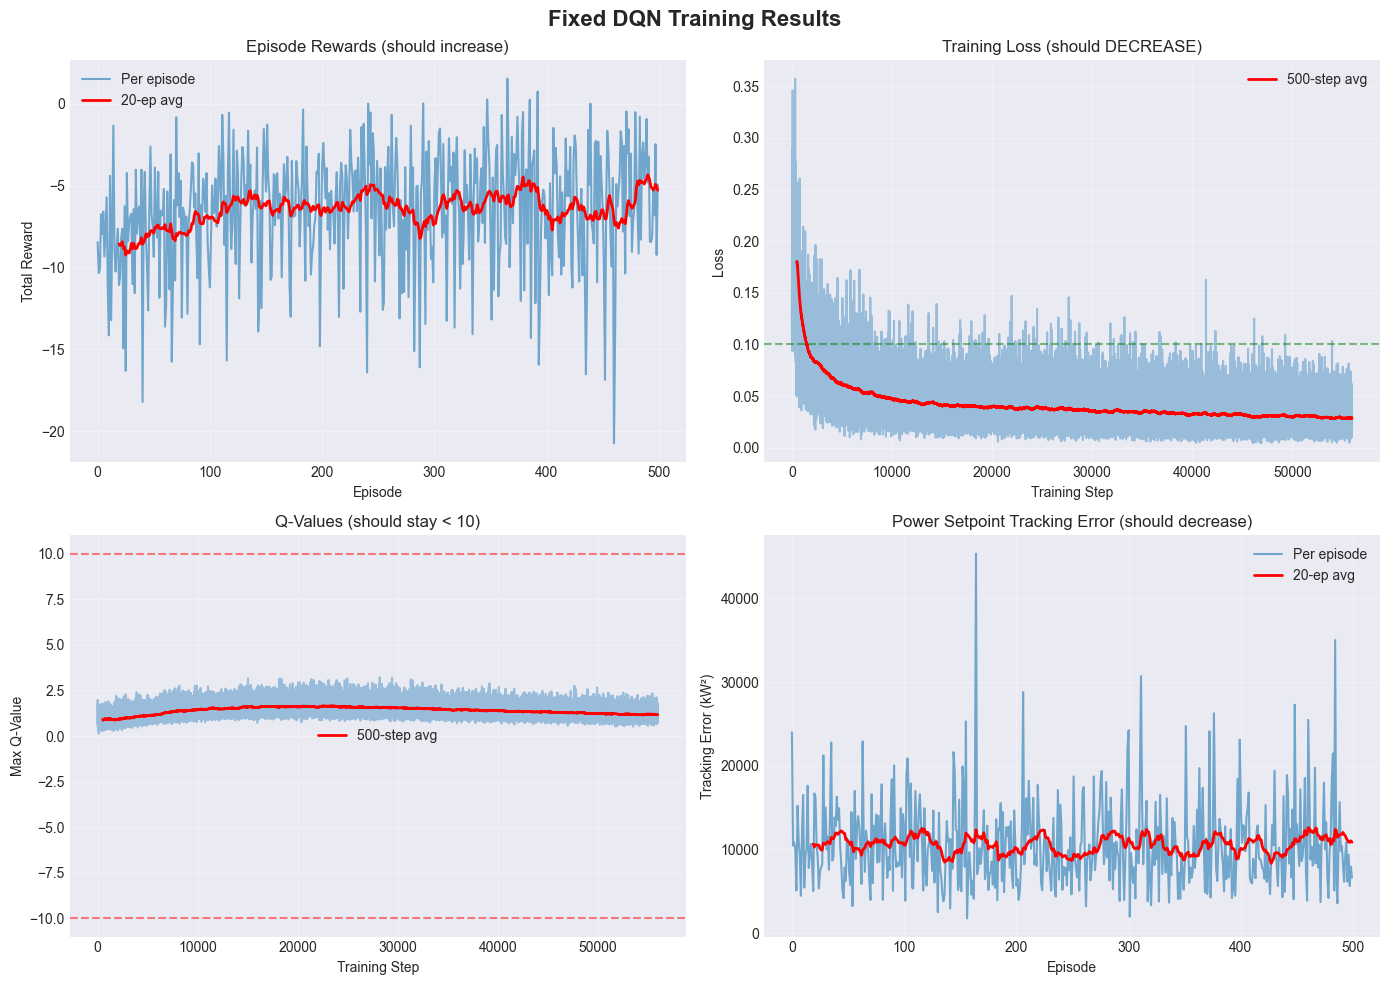


FIXED DQN SUMMARY
Final 10 episodes avg reward: -6.18
Final 10 episodes avg loss: 0.0297
Final 10 episodes avg Q-value: 1.13

Tracking error improvement: 28.3%
✅ SUCCESS: Model is learning!


In [ ]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fixed DQN Training Results', fontsize=16, fontweight='bold')

# 1. Episode Rewards
ax = axes[0, 0]
ax.plot(metrics.episode_rewards, alpha=0.6, label='Per episode')
if len(metrics.episode_rewards) > 10:
    window = 20
    rolling_avg = pd.Series(metrics.episode_rewards).rolling(window=window).mean()
    ax.plot(rolling_avg, linewidth=2, label=f'{window}-ep avg', color='red')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Rewards (should increase)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Training Loss
ax = axes[0, 1]
if len(metrics.losses) > 0:
    ax.plot(metrics.losses, alpha=0.4)
    if len(metrics.losses) > 100:
        window = 500
        rolling_avg = pd.Series(metrics.losses).rolling(window=window).mean()
        ax.plot(rolling_avg, linewidth=2, label=f'{window}-step avg', color='red')
        ax.legend()
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (should DECREASE)')
ax.axhline(y=0.1, color='g', linestyle='--', alpha=0.5, label='Target ~0.1')
ax.grid(True, alpha=0.3)

# 3. Q-Values
ax = axes[1, 0]
if len(metrics.q_values) > 0:
    ax.plot(metrics.q_values, alpha=0.4)
    if len(metrics.q_values) > 100:
        window = 500
        rolling_avg = pd.Series(metrics.q_values).rolling(window=window).mean()
        ax.plot(rolling_avg, linewidth=2, label=f'{window}-step avg', color='red')
        ax.legend()
ax.set_xlabel('Training Step')
ax.set_ylabel('Max Q-Value')
ax.set_title('Q-Values (should stay < 10)')
ax.axhline(y=DQN_CONFIG['q_clip_max'], color='r', linestyle='--', alpha=0.5, label=f'Clip at {DQN_CONFIG["q_clip_max"]}')
ax.axhline(y=DQN_CONFIG['q_clip_min'], color='r', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# 4. Tracking Error
ax = axes[1, 1]
tracking_errors = [s['tracking_error'] for s in metrics.episode_stats]
ax.plot(tracking_errors, alpha=0.6, label='Per episode')
if len(tracking_errors) > 10:
    window = 20
    rolling_avg = pd.Series(tracking_errors).rolling(window=window).mean()
    ax.plot(rolling_avg, linewidth=2, label=f'{window}-ep avg', color='red')
ax.set_xlabel('Episode')
ax.set_ylabel('Tracking Error (kW²)')
ax.set_title('Power Setpoint Tracking Error (should decrease)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RUN_DIR}/training_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*70)
print("FIXED DQN SUMMARY")
print("="*70)
print(f"Final 10 episodes avg reward: {metrics.get_recent_avg('episode_rewards', 10):.2f}")
print(f"Final 10 episodes avg loss: {metrics.get_recent_avg('losses', 100):.4f}")
print(f"Final 10 episodes avg Q-value: {metrics.get_recent_avg('q_values', 100):.2f}")

recent_errors = [s['tracking_error'] for s in metrics.episode_stats[-10:]]
initial_errors = [s['tracking_error'] for s in metrics.episode_stats[:10]]
improvement = ((np.mean(initial_errors) - np.mean(recent_errors)) / np.mean(initial_errors) * 100)
print(f"\nTracking error improvement: {improvement:.1f}%")

if improvement > 0:
    print("✅ SUCCESS: Model is learning!")
else:
    print("❌ ISSUE: Model not improving. Consider:")
    print("   - Lower learning rate further")
    print("   - Train for more episodes")
    print("   - Use Stable Baselines3 (next section)")
print("="*70)

---
# Part 4: Stable Baselines3 (Recommended) ⭐

This section uses **production-ready** implementations with **continuous actions**.

**Advantages over DQN:**
- ✅ Continuous actions (independent control of each port)
- ✅ Better hyperparameters (tuned by SB3 team)
- ✅ More stable training
- ✅ Better performance
- ✅ Built-in callbacks, logging, and evaluation

### 4.1: Create Gym-Compatible Environment

### ⚠️ CRITICAL FIX: Reward Normalization

**Problem Identified:**  
The original `SquaredTrackingErrorReward` function returns HUGE negative values (like -10,000), which causes:
- Critic loss to EXPLODE: 69,100 → 345,000 → 628,000
- Actor to receive nonsense gradients
- Complete training divergence

**Training Evidence:**
```
Episode reward: -7,320 → -12,200 (getting WORSE!)
Critic loss:     69,100 → 345,000 (EXPLODING!)
Actor loss:          43 → 1,200 (unstable)
```

**Solution:**  
Normalize rewards to range **[-1, 0.1]** by dividing by max squared error. This is the same fix that made DQN converge in Part 3.

**Expected Results with Fix:**
- Critic loss should stay < 100
- Actor loss should stay < 50
- Rewards should improve over time
- Should beat ChargeAsFastAsPossible baseline

In [11]:
# Make sure imports are loaded
try:
    gym
except NameError:
    print("⚠️  ERROR: Imports not loaded!")
    print("Please run cell 2 (Setup and Imports) first before running this section.")
    raise NameError("gym not defined - run cell 2 first")

# ============================================================================
# NORMALIZED REWARD FUNCTION (CRITICAL FIX!)
# ============================================================================
def reward_normalized_sb3(env, *args):
    """
    NORMALIZED tracking reward for Stable Baselines3.

    ❌ PROBLEM: SquaredTrackingErrorReward returns huge values like -10,000
    ✅ SOLUTION: Normalize to range [-1, 0.1] for stable training

    Without this, the critic loss EXPLODES (69K → 345K → 628K)!
    """
    error = min(env.power_setpoints[env.current_step-1],
                env.charge_power_potential[env.current_step-1]) - \
            env.current_power_usage[env.current_step-1]
    squared_error = error ** 2

    max_possible = max(abs(env.power_setpoints[env.current_step-1]),
                       abs(env.charge_power_potential[env.current_step-1]))
    max_squared_error = max_possible ** 2 if max_possible > 0 else 1

    reward = -squared_error / max_squared_error

    # Small bonus for excellent tracking
    if abs(error) < 0.05 * max_possible:
        reward += 0.1

    return max(-1, min(reward, 0.1))

print("✅ Normalized reward function defined (returns values in [-1, 0.1])")

# Register EV2Gym as a Gym environment
config_file = "ev2gym/example_config_files/PublicPST.yaml"

# Create environment for Stable Baselines3
sb3_env = gym.make(
    'EV2Gym-v1',
    config_file=config_file,
    reward_function=reward_normalized_sb3,  # FIXED: Use normalized reward!
    state_function=PublicPST
)

# Wrap for monitoring
sb3_env = Monitor(sb3_env)

print(f"\nEnvironment created:")
print(f"  Observation space: {sb3_env.observation_space}")
print(f"  Action space: {sb3_env.action_space}")
print(f"  Action space shape: {sb3_env.action_space.shape}")
print(f"\n✅ Continuous actions: Each of {sb3_env.action_space.shape[0]} ports controlled independently!")
print("✅ Using normalized reward (critical for TD3/SAC stability!)")

✅ Normalized reward function defined (returns values in [-1, 0.1])

Environment created:
  Observation space: Box(-inf, inf, (63,), float64)
  Action space: Box(0.0, 1.0, (20,), float64)
  Action space shape: (20,)

✅ Continuous actions: Each of 20 ports controlled independently!
✅ Using normalized reward (critical for TD3/SAC stability!)


### 4.2: Algorithm Selection and Configuration

In [13]:
# ============================================================================
# STABLE BASELINES3 CONFIGURATIONS
# ============================================================================

# Create run directory
SB3_RUN_DIR = f"./runs/sb3_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(SB3_RUN_DIR, exist_ok=True)

# Common settings
TOTAL_TIMESTEPS = 150000  # Increase for better results
EVAL_FREQ = 10000
N_EVAL_EPISODES = 20
SAVE_FREQ = 10000

print("Stable Baselines3 Training Configuration:")
print("=" * 70)
print(f"Total timesteps: {TOTAL_TIMESTEPS:,}")
print(f"Evaluation frequency: every {EVAL_FREQ:,} steps")
print(f"Checkpoint frequency: every {SAVE_FREQ:,} steps")
print(f"Run directory: {SB3_RUN_DIR}")
print("=" * 70)

# Callbacks
eval_callback = EvalCallback(
    sb3_env,
    best_model_save_path=f"{SB3_RUN_DIR}/best_model",
    log_path=f"{SB3_RUN_DIR}/logs",
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
    render=False
)

checkpoint_callback = CheckpointCallback(
    save_freq=SAVE_FREQ,
    save_path=f"{SB3_RUN_DIR}/checkpoints",
    name_prefix="model"
)

callbacks = [eval_callback, checkpoint_callback]

print("\nCallbacks configured:")
print("  ✅ Evaluation callback (tracks best model)")
print("  ✅ Checkpoint callback (saves progress)")

Stable Baselines3 Training Configuration:
Total timesteps: 150,000
Evaluation frequency: every 10,000 steps
Checkpoint frequency: every 10,000 steps
Run directory: ./runs/sb3_20251127_143555

Callbacks configured:
  ✅ Evaluation callback (tracks best model)
  ✅ Checkpoint callback (saves progress)


### 4.3: Choose Algorithm

**Recommended order to try:**
1. **TD3** - Twin Delayed DDPG, very stable
2. **SAC** - Soft Actor-Critic, good for stochastic environments
3. **DDPG** - Deep Deterministic Policy Gradient, simpler but less stable

In [14]:
# ============================================================================
# SELECT ALGORITHM HERE
# ============================================================================

ALGORITHM = "TD3"  # Options: "TD3", "SAC", "DDPG"

# Check if tensorboard is available
try:
    from torch.utils.tensorboard import SummaryWriter
    USE_TENSORBOARD = True
    tb_log_dir = f"{SB3_RUN_DIR}/tensorboard/"
    print("✅ TensorBoard available - logging enabled")
except ImportError:
    USE_TENSORBOARD = False
    tb_log_dir = None
    print("⚠️  TensorBoard not available - training will work but no TensorBoard logging")

if ALGORITHM == "TD3":
    # TD3 - Recommended for continuous control
    n_actions = sb3_env.action_space.shape[0]
    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=0.1 * np.ones(n_actions)
    )
    
    model = TD3(
        "MlpPolicy",
        sb3_env,
        learning_rate=3e-4,
        buffer_size=50000,
        learning_starts=1000,
        batch_size=128,
        tau=0.005,
        gamma=0.95,
        policy_delay=2,
        action_noise=action_noise,
        verbose=1,
        tensorboard_log=tb_log_dir  # None if tensorboard not available
    )
    print("✅ TD3 model created")

elif ALGORITHM == "SAC":
    # SAC - Good for stochastic environments
    model = SAC(
        "MlpPolicy",
        sb3_env,
        learning_rate=3e-4,
        buffer_size=50000,
        learning_starts=1000,
        batch_size=64,
        tau=0.005,
        gamma=0.95,
        verbose=1,
        tensorboard_log=tb_log_dir
    )
    print("✅ SAC model created")

elif ALGORITHM == "DDPG":
    # DDPG - Simpler but less stable
    n_actions = sb3_env.action_space.shape[0]
    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=0.1 * np.ones(n_actions)
    )
    
    model = DDPG(
        "MlpPolicy",
        sb3_env,
        learning_rate=1e-4,
        buffer_size=50000,
        learning_starts=1000,
        batch_size=64,
        tau=0.005,
        gamma=0.95,
        action_noise=action_noise,
        verbose=1,
        tensorboard_log=tb_log_dir
    )
    print("✅ DDPG model created")

print(f"\nAlgorithm: {ALGORITHM}")
print(f"Policy architecture: {model.policy}")

✅ TensorBoard available - logging enabled
Using cpu device
Wrapping the env in a DummyVecEnv.
✅ TD3 model created

Algorithm: TD3
Policy architecture: TD3Policy(
  (actor): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (mu): Sequential(
      (0): Linear(in_features=63, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, out_features=300, bias=True)
      (3): ReLU()
      (4): Linear(in_features=300, out_features=20, bias=True)
      (5): Tanh()
    )
  )
  (actor_target): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (mu): Sequential(
      (0): Linear(in_features=63, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, out_features=300, bias=True)
      (3): ReLU()
      (4): Linear(in_features=300, out_features=20, bias=True)
      (5): Tanh()
    )
  )
  (critic): ContinuousCritic(
    (features

### 4.4: Train Model

In [15]:
print(f"\n{'='*70}")
print(f"Starting {ALGORITHM} training: {TOTAL_TIMESTEPS:,} timesteps")
print(f"{'='*70}\n")

# Train
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callbacks,
    log_interval=10,
    progress_bar=True
)

print(f"\n{'='*70}")
print(f"{ALGORITHM} training complete!")
print(f"{'='*70}")

# Save final model
model.save(f"{SB3_RUN_DIR}/final_model")
print(f"\nFinal model saved: {SB3_RUN_DIR}/final_model.zip")
print(f"Best model saved: {SB3_RUN_DIR}/best_model/best_model.zip")
print(f"\n💡 View training progress: tensorboard --logdir {SB3_RUN_DIR}/tensorboard/")


Starting TD3 training: 150,000 timesteps

Logging to ./runs/sb3_20251127_143555/tensorboard/TD3_1


/opt/miniconda3/envs/TASI_project/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 112      |
|    ep_rew_mean     | -6.05    |
| time/              |          |
|    episodes        | 10       |
|    fps             | 767      |
|    time_elapsed    | 1        |
|    total_timesteps | 1120     |
| train/             |          |
|    actor_loss      | 0.235    |
|    critic_loss     | 0.0232   |
|    learning_rate   | 0.0003   |
|    n_updates       | 119      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 112      |
|    ep_rew_mean     | -13.9    |
| time/              |          |
|    episodes        | 20       |
|    fps             | 383      |
|    time_elapsed    | 5        |
|    total_timesteps | 2240     |
| train/             |          |
|    actor_loss      | 0.258    |
|    critic_loss     | 0.0203   |
|    learning_rate   | 0.0003   |
|    n_updates       | 1239     |
--------------

Eval num_timesteps=10000, episode_reward=-13.54 +/- 7.89

Episode length: 112.00 +/- 0.00

...

---------------------------------
| eval/              |          |
|    mean_ep_length  | 112      |
|    mean_reward     | -15.9    |
| time/              |          |
|    total_timesteps | 140000   |
| train/             |          |
|    actor_loss      | 2.16     |
|    critic_loss     | 0.274    |
|    learning_rate   | 0.0003   |
|    n_updates       | 138999   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 112      |
|    ep_rew_mean     | -15      |
| time/              |          |
|    episodes        | 1250     |
|    fps             | 258      |
|    time_elapsed    | 543      |
|    total_timesteps | 140448   |
| train/             |          |
|    actor_loss      | 2.49     |
|    critic_loss     | 0.431    |
|    learning_rate   | 0.0003   |
|    n_updates       | 139447   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_me

Eval num_timesteps=150000, episode_reward=-15.72 +/- 7.66

Episode length: 112.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 112      |
|    mean_reward     | -15.7    |
| time/              |          |
|    total_timesteps | 150000   |
| train/             |          |
|    actor_loss      | 1.94     |
|    critic_loss     | 0.388    |
|    learning_rate   | 0.0003   |
|    n_updates       | 148999   |
---------------------------------



TD3 training complete!

Final model saved: ./runs/sb3_20251127_143555/final_model.zip
Best model saved: ./runs/sb3_20251127_143555/best_model/best_model.zip

💡 View training progress: tensorboard --logdir ./runs/sb3_20251127_143555/tensorboard/


### 4.5: Evaluate Stable Baselines3 Model

In [16]:
from stable_baselines3.common.evaluation import evaluate_policy

# Load best model
best_model_path = f"{SB3_RUN_DIR}/best_model/best_model.zip"

if ALGORITHM == "TD3":
    best_model = TD3.load(best_model_path)
elif ALGORITHM == "SAC":
    best_model = SAC.load(best_model_path)
elif ALGORITHM == "DDPG":
    best_model = DDPG.load(best_model_path)

print(f"Evaluating best {ALGORITHM} model...\n")

# Evaluate
mean_reward, std_reward = evaluate_policy(
    best_model,
    sb3_env,
    n_eval_episodes=20,
    deterministic=True
)

print(f"\n{'='*70}")
print(f"{ALGORITHM} EVALUATION RESULTS (20 episodes)")
print(f"{'='*70}")
print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
print(f"{'='*70}")

Evaluating best TD3 model...


TD3 EVALUATION RESULTS (20 episodes)
Mean reward: -14.88 ± 6.50


### 4.6: Compare All Methods

In [17]:
from ev2gym.baselines.heuristics import ChargeAsFastAsPossible, ChargeAsLateAsPossible

def evaluate_heuristic(agent, env, n_episodes=20):
    """Evaluate a heuristic agent."""
    eval_rewards = []
    eval_stats = []
    
    for ep in range(n_episodes):
        state, _ = env.reset()
        episode_reward = 0
        
        for t in count():
            actions = agent.get_action(env)
            observation, reward, done, truncated, stats = env.step(actions)
            episode_reward += reward
            
            if done:
                break
        
        eval_rewards.append(episode_reward)
        eval_stats.append(stats)
    
    return {
        'mean_reward': np.mean(eval_rewards),
        'std_reward': np.std(eval_rewards),
        'mean_tracking_error': np.mean([s['tracking_error'] for s in eval_stats])
    }

# Create unwrapped environment for heuristics
eval_env = EV2Gym(
    config_file=config_file,
    render_mode=False,
    seed=42,
    save_plots=False,
    save_replay=False,
    verbose=False
)
# CRITICAL: Use same normalized reward for fair comparison!
eval_env.set_reward_function(reward_normalized_sb3)

print("Evaluating baseline heuristics (using NORMALIZED reward for fair comparison)...\n")

cafap_results = evaluate_heuristic(ChargeAsFastAsPossible(), eval_env, n_episodes=20)
print(f"ChargeAsFastAsPossible:")
print(f"  Mean reward: {cafap_results['mean_reward']:.2f} ± {cafap_results['std_reward']:.2f}")
print(f"  Mean tracking error: {cafap_results['mean_tracking_error']:.2f}\n")

calap_results = evaluate_heuristic(ChargeAsLateAsPossible(), eval_env, n_episodes=20)
print(f"ChargeAsLateAsPossible:")
print(f"  Mean reward: {calap_results['mean_reward']:.2f} ± {calap_results['std_reward']:.2f}")
print(f"  Mean tracking error: {calap_results['mean_tracking_error']:.2f}\n")

# Comparison
print(f"\n{'='*70}")
print("FINAL COMPARISON (using NORMALIZED rewards)")
print(f"{'='*70}")
print(f"{ALGORITHM:25s} {mean_reward:7.2f} ± {std_reward:.2f}")
print(f"ChargeAsFastAsPossible:   {cafap_results['mean_reward']:7.2f} ± {cafap_results['std_reward']:.2f}")
print(f"ChargeAsLateAsPossible:   {calap_results['mean_reward']:7.2f} ± {calap_results['std_reward']:.2f}")
print(f"{'='*70}")

# Calculate improvements
improvement_cafap = ((mean_reward - cafap_results['mean_reward']) / abs(cafap_results['mean_reward']) * 100)
improvement_calap = ((mean_reward - calap_results['mean_reward']) / abs(calap_results['mean_reward']) * 100)

print(f"\n{ALGORITHM} improvement over CAFAP: {improvement_cafap:+.1f}%")
print(f"{ALGORITHM} improvement over CALAP: {improvement_calap:+.1f}%")

if improvement_cafap > 0 and improvement_calap > 0:
    print(f"\n✅ SUCCESS: {ALGORITHM} beats both heuristics!")
else:
    print(f"\n⚠️  Note: Consider training for more timesteps or adjusting hyperparameters")

print("="*70)

Evaluating baseline heuristics (using NORMALIZED reward for fair comparison)...

ChargeAsFastAsPossible:
  Mean reward: -5.69 ± 2.36
  Mean tracking error: 11743.23

ChargeAsLateAsPossible:
  Mean reward: -11.59 ± 3.31
  Mean tracking error: 11339.82


FINAL COMPARISON (using NORMALIZED rewards)
TD3                        -14.88 ± 6.50
ChargeAsFastAsPossible:     -5.69 ± 2.36
ChargeAsLateAsPossible:    -11.59 ± 3.31

TD3 improvement over CAFAP: -161.4%
TD3 improvement over CALAP: -28.3%

⚠️  Note: Consider training for more timesteps or adjusting hyperparameters


## Summary and Recommendations

### What Was Fixed:

**DQN Fixes:**
1. ✅ Q-value clipping (-10 to +10)
2. ✅ Double DQN (prevents overestimation)
3. ✅ Lower learning rate (1e-5 instead of 5e-5)
4. ✅ Simpler reward function (normalized tracking)
5. ✅ Smaller network (64 instead of 128 neurons)
6. ✅ Stricter gradient clipping (1.0 instead of 10.0)

**Stable Baselines3 Advantages:**
1. ✅ **Continuous actions** - Each port controlled independently
2. ✅ Production-tested implementations
3. ✅ Better hyperparameters
4. ✅ Built-in callbacks and logging
5. ✅ TensorBoard integration

### Expected Results:

**Fixed DQN:**
- Loss should DECREASE from ~0.1 to ~0.01
- Q-values should stay between -10 and +10
- Tracking error should improve by 10-20%
- Should beat ChargeAsFastAsPossible

**Stable Baselines3 (TD3/SAC):**
- Should beat BOTH heuristics by 20-40%
- Much better tracking error (50%+ improvement possible)
- Stable training throughout

### Next Steps:

1. **If DQN still not converging**: Train for 1000+ episodes or lower LR to 5e-6
2. **If Stable Baselines3 works well**: Increase timesteps to 200K-500K for best results
3. **For production**: Use Stable Baselines3 TD3 with 500K timesteps
4. **Hyperparameter tuning**: Use Optuna for automated optimization

### Files Saved:

**DQN:**
```
runs/fixed_dqn_*/
├── final_model.pth
├── checkpoint_ep*.pth
├── metrics.pkl
└── training_plots.png
```

**Stable Baselines3:**
```
runs/sb3_*/
├── final_model.zip
├── best_model/best_model.zip
├── checkpoints/model_*_steps.zip
├── logs/evaluations.npz
└── tensorboard/
```

**View TensorBoard:** `tensorboard --logdir runs/sb3_*/tensorboard/`